## **Atelier Matplotlib**

## Installer et importer matplotlib et pandas

In [4]:
# Import des bibliothèques nécessaires pour tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version    :", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("NumPy version     :", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Pandas version    : 3.0.3
Matplotlib version: 3.11.1
NumPy version     : 2.5.0


 Import de `mesures_capteurs.csv` dans le dataframe `df`

In [5]:
# Import du CSV dans le dataframe df
# Le chemin est relatif au notebook, situé dans notebooks/, le CSV est dans ../data/
df = pd.read_csv("../data/mesures_capteurs.csv")

# Conversion de la colonne date_heure en type datetime pour un tracé correct de l'axe temporel
df["date_heure"] = pd.to_datetime(df["date_heure"])

print("Dimensions du dataframe :", df.shape)
df.head()

Dimensions du dataframe : (605, 9)


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [6]:
# Verifion rapidement des valeurs manquantes : utile pour anticiper les graphiques
# (certaines colonnes contiennent quelques NaN à gérer avant de tracer)
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

## Partie 1 – Graphique linéaire (Line Plot)

1) Évolution de la température en fonction du temps, avec titre, labels, légende et grille

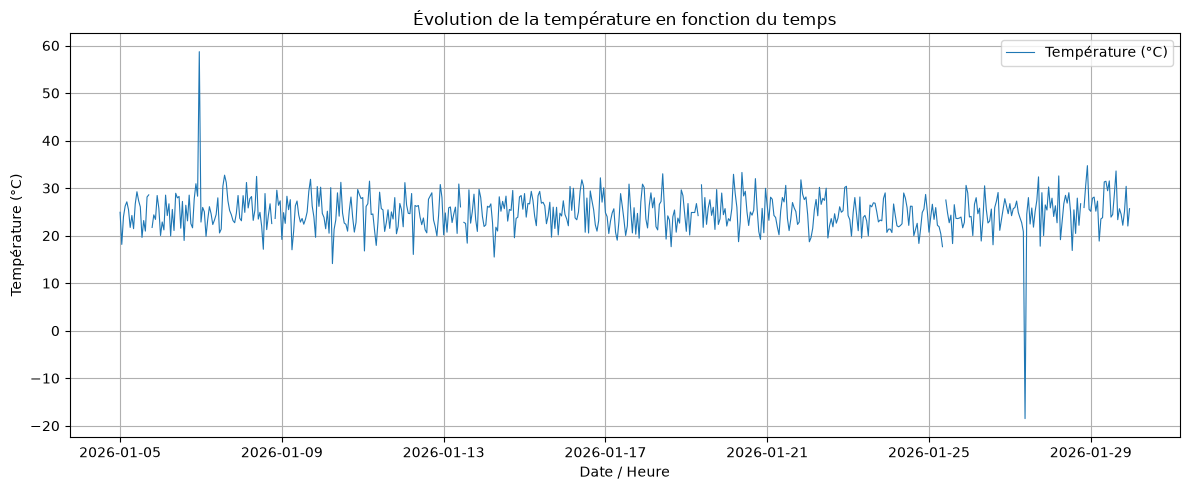

In [7]:
# On trie par date_heure pour que la courbe suive bien l'ordre chronologique
df_temps = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_temps["date_heure"], df_temps["temperature"],
         color="tab:blue", linewidth=0.8, label="Température (°C)")

plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2) Identification visuelle des valeurs qui semblent anormales

In [8]:
# Quelques repères chiffrés pour appuyer la lecture visuelle du graphique
print("Température minimale :", df["temperature"].min())
print("Température maximale :", df["temperature"].max())
print(df.nsmallest(3, "temperature")[["date_heure", "batiment", "temperature"]])
print(df.nlargest(3, "temperature")[["date_heure", "batiment", "temperature"]])

Température minimale : -18.5
Température maximale : 58.7
             date_heure batiment  temperature
487 2026-01-27 09:00:00     B004       -18.50
245 2026-01-10 06:00:00     B003        14.11
258 2026-01-14 06:00:00     B003        15.49
             date_heure batiment  temperature
502 2026-01-06 23:00:00     B004        58.70
43  2026-01-28 22:00:00     B004        34.72
129 2026-01-29 15:00:00     B002        33.60


**Explication**

Sur la courbe, l'immense majorité des points oscille dans une bande resserrée, à peu près entre 15 °C et 35 °C, avec de petites fluctuations d'une mesure à l'autre — un comportement cohérent avec des variations normales de température ambiante. Deux valeurs se détachent nettement de ce nuage : un point autour de **-18,5 °C**, physiquement improbable pour une mesure intérieure/ambiante, et un point autour de **58,7 °C**, largement au-dessus du reste des mesures. Ces deux valeurs forment des pics isolés, sans continuité avec les mesures voisines dans le temps, ce qui est typique d'une **erreur de capteur** (défaut de calibration, court-circuit, valeur de remplacement type -999 mal codée, etc.) plutôt que d'un phénomène physique réel.

###  Résumé — Partie 1 : Graphique linéaire

| Fonction / Méthode utilisée | Ce qu'elle fait | Alternative existante (non utilisée) | Différence avec l'alternative |
|---|---|---|---|
| `plt.plot(x, y)` | Trace une courbe reliant des points par des segments de droite | `plt.scatter(x, y)` | `scatter` affiche des points isolés sans les relier ; moins adapté pour suivre une évolution continue dans le temps. |
| `plt.title()` / `.xlabel()` / `.ylabel()` | Ajoute titre et légendes des axes | `plt.suptitle()` | `suptitle` place un titre au-dessus de plusieurs sous-graphiques (subplots), alors que `title()` s'applique à un seul axe. |
| `plt.legend()` | Affiche la légende à partir du paramètre `label=` des tracés | Placer le texte manuellement avec `plt.text()` | `text()` positionne une légende « à la main », sans lien automatique avec les couleurs/styles des courbes tracées. |
| `plt.grid(True)` | Affiche une grille sur les deux axes | `plt.grid(axis="y")` | Restreint la grille à un seul axe (utilisé en Partie 3 et 5 pour n'afficher que les lignes horizontales). |
| `df.nsmallest()` / `df.nlargest()` | Renvoie les n lignes avec les plus petites/grandes valeurs d'une colonne | `df.sort_values().head(n)` | Résultat identique ; `nsmallest`/`nlargest` est plus direct et légèrement plus rapide sur de grands jeux de données. |